# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [234]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from pipeline.extract import extract, establish_tiingo_connection
from pipeline.transform import transform


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [215]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-26,672.36,675.2800,661.2855,665.125,16327378,671.797893,674.715452,660.732652,664.568942,...,675.2800,661.2855,675.2800,644.4450,1,-0.082474,0.797085,0.134021,0.216495,0.649485
1,2026-01-27,672.97,676.8150,664.6600,674.590,13148719,672.407383,676.249169,664.104331,674.026029,...,676.8150,661.2855,676.8150,644.4450,2,0.158879,0.790941,0.299065,0.140187,0.560748
2,2026-01-28,668.73,677.6775,666.1000,674.500,25709600,668.170928,677.110948,665.543127,673.936104,...,677.6775,661.2855,677.6775,661.2855,3,0.170543,0.801010,0.302326,0.131783,0.565891
3,2026-01-29,738.31,744.0000,712.5500,737.430,59852903,737.692758,743.378001,711.954294,736.813493,...,744.0000,664.6600,744.0000,661.2855,4,-0.027027,0.806134,0.209459,0.236486,0.554054
4,2026-01-30,716.50,732.1700,713.5900,727.500,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,666.1000,744.0000,661.2855,5,-0.109375,0.837781,0.156250,0.265625,0.578125


## Check Device

In [216]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [217]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      6.687300e+02
previous_day_close                         6.729700e+02
previous_day_high                          6.768150e+02
previous_day_low                           6.646600e+02
previous_day_open                          6.745900e+02
previous_day_volume                        1.314872e+07
1_day_max                                  6.776775e+02
1_day_min                                  6.661000e+02
3_day_max                                  6.776775e+02
3_day_min                                  6.612855e+02
5_day_max                                  6.776775e+02
5_day_min                                  6.612855e+02
day_of_week                                3.000000e+00
previous_day_numerical_sentiment           1.588785e-01
previous_day_mean_sentiment_probability    7.909406e-01
previous_day_percent_positive              2.990654e-01
previous_day_percent_negative              1.401869e-01
previous_day_percent_neutral               5.607

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

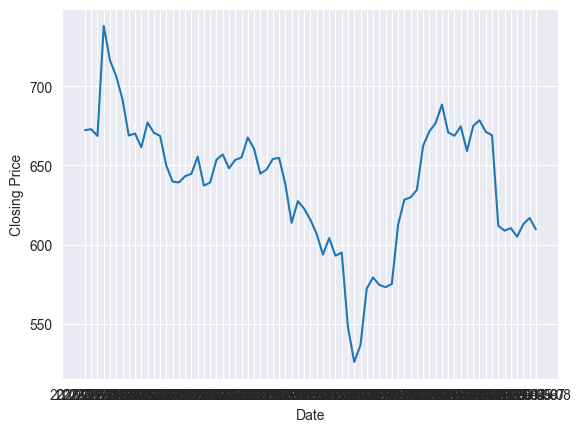

In [218]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [219]:
df = df.dropna()

## Scale Data

In [220]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.7)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy

array([[ 0.81252948,  0.67204247,  0.7707535 ,  0.62079621,  0.03208378,
         0.72964089,  0.88034998,  0.5588976 ,  0.98988966,  0.46298884,
         0.6550222 , -0.71864814, -0.33823726, -0.82116289, -0.71433904,
        -0.09806589,  0.57444179],
       [ 0.82634177,  0.7066447 ,  0.84869767,  0.83604596, -0.33456034,
         0.74915195,  0.91359472,  0.57889454,  0.98988966,  0.48310519,
         1.04532165,  0.01466629,  1.65947803, -1.1695425 ,  1.67151476,
        -0.97314237, -0.30492506],
       [ 0.73033503,  0.72608732,  0.88195877,  0.83399921,  1.1142812 ,
         2.24946771,  1.9859685 ,  2.11657225,  1.0697245 ,  2.02996529,
         1.04532165,  0.74798072,  1.75602391, -0.5986069 ,  1.71864298,
        -1.06951658, -0.25395081],
       [ 2.30584184,  2.22114022,  1.9548604 ,  2.26513148,  5.05255874,
         1.98185513,  2.00997859,  2.11657225,  1.10379241,  2.02996529,
         1.04532165,  1.48129515,  0.12070811, -0.30807293,  0.37618937,
         0.13119227

## Split Data Train/Test

In [221]:
X_train = X_train_df_as_numpy.reshape((-1, 17, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 17, 1))
Y_test = Y_test_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((50, 17, 1), (50, 1), (22, 17, 1), (22, 1))

## Convert To Tensors

In [222]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([50, 17, 1]),
 torch.Size([50, 1]),
 torch.Size([22, 17, 1]),
 torch.Size([22, 1]))

## Dataset Class

In [223]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [224]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

50

## Dataloaders

In [225]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [226]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([2, 17, 1]) torch.Size([2, 1])


## Define Neural Network

In [227]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [228]:
model = Net(1, 32, 4, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=4, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [229]:
lr = 1e-3
num_epochs = 500
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.0208582878112793
25 0.6668990254402161
50 0.21764473617076874
75 0.1307256668806076
100 0.10080825537443161
125 0.09750218689441681
150 0.09426417946815491
175 0.09034617245197296
200 0.08436594903469086
225 0.07622389495372772
250 0.06844356656074524
275 0.06128256767988205
300 0.05442313104867935
325 0.05628124624490738
350 0.0468040406703949
375 0.03660019859671593
400 0.05315371975302696
425 0.026656635105609894
450 0.01974395290017128
475 0.016203276813030243


## Testing

In [230]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((50, 1), (50, 1), (22, 1), (22, 1))

In [231]:
train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
test_rmse = root_mean_squared_error(test_actual, test_output_prediction)


In [232]:
{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 5.2791852951049805, 'test_rmse': 13.203835487365723}

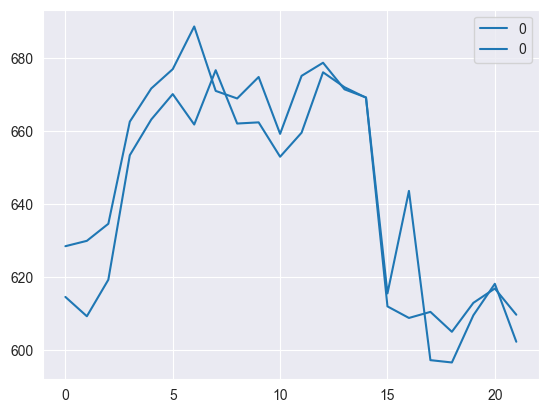

In [233]:


actual_line = sns.lineplot(test_actual)
predicted_line = sns.lineplot(test_output_prediction)

